# Fixed-layout 3-patch two-layer optimizer — single mode at natural frequency

This is a deliberately simplified skeleton.

**Outer layer:** optimize only the three active patch lengths and the two substrate gaps between patches:

$$
\mathbf z=[\ell_1,\; g_{12},\; \ell_2,\; g_{23},\; \ell_3].
$$

The region sequence is always fixed:

```python
['piezo', 'substrate', 'piezo', 'substrate', 'piezo', 'substrate']
```

So the first patch starts at the root, and the last substrate segment is the remaining tip region.

**Inner layer:** for a candidate geometry, the FE model is rebuilt and its natural frequencies are recomputed. For the selected target mode, the code evaluates the response only at that geometry's natural frequency:

$$
\omega_m(\mathbf g)=2\pi f_m(\mathbf g).
$$

All patches use the same amplitude and frequency. The only optimized actuation variable is the binary phase/sign vector:

$$
\mathbf s \in \{-1,+1\}^3.
$$

The objective is the best tip displacement per volt at the selected natural frequency.

A final dense FRF sweep is kept only for plotting/verification after optimization. It is **not** used inside the optimizer.


## 0. Imports

Edit `PROJECT_ROOT` if the `Modeling` imports fail. It should point to the folder that contains the `Modeling/` directory.


In [14]:
from __future__ import annotations

import copy
import itertools
import sys
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize, OptimizeResult
from scipy.signal import find_peaks
from tqdm.auto import tqdm

# -------------------------------------------------------------------------
# EDIT THIS if imports fail.
# Usually this should be the folder containing Modeling/.
# -------------------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parents[2]
sys.path.append(str(PROJECT_ROOT))

from Modeling.models.beam_properties import PiezoBeamParams
import Modeling.models.FE3 as FE_module
import Modeling.models.FE_helpers as FE_helpers

# FE_helpers.frf_sweep uses tqdm internally. Disable it during optimization to avoid
# thousands of progress bars.
QUIET_FRF_SWEEP = True
if QUIET_FRF_SWEEP:
    FE_helpers.tqdm = lambda iterable, *args, **kwargs: iterable

print("FE_module:", FE_module.__file__)
print("FE_helpers:", FE_helpers.__file__)


FE_module: c:\Users\dlie9\OneDrive - Georgia Institute of Technology\General - Swimmers\Software\Arduino\Arduino Playground\FishCode\multi_mfc_control\Modeling\models\FE3.py
FE_helpers: c:\Users\dlie9\OneDrive - Georgia Institute of Technology\General - Swimmers\Software\Arduino\Arduino Playground\FishCode\multi_mfc_control\Modeling\models\FE_helpers.py


## 1. Define region material/section properties

This section mirrors the arbitrary-placement test style: define `region_types`, then let `build_geometry_from_types(...)` create the mesh and automatically detect regions named `'piezo'` as active piezo actuators.

For this simplified notebook, the only two region names are:

- `piezo`: active piezo-covered composite section,
- `substrate`: bare substrate section.

If you later want Kapton margins again, add them back into `region_sequence`, but this simplified skeleton intentionally keeps the sequence fixed to six regions.


In [15]:
def compute_EI_and_rhoA(E_layers, rho_layers, h_layers, b_layers):
    """
    Compute bending stiffness EI and mass per unit length rhoA
    for a symmetric layered beam section.

    Layer convention:
    - layer 0 is the center/mid-layer, mirrored about y=0
    - layers 1, 2, ... are stacked outward symmetrically
    """
    E_layers = np.asarray(E_layers, dtype=float)
    rho_layers = np.asarray(rho_layers, dtype=float)
    h_layers = np.asarray(h_layers, dtype=float)
    b_layers = np.asarray(b_layers, dtype=float)

    assert len(E_layers) == len(rho_layers) == len(h_layers) == len(b_layers)

    y = [h_layers[0] / 2.0]
    for i in range(1, len(h_layers)):
        y.append(y[i-1] + h_layers[i])

    EI_half = 0.0
    rhoA_half = 0.0
    for i, (E, rho, h, b) in enumerate(zip(E_layers, rho_layers, h_layers, b_layers)):
        if i == 0:
            # center layer contributes half-thickness on positive side
            EI_half += E * b * y[i]**3 / 3.0
            rhoA_half += rho * b * h / 2.0
        else:
            EI_half += E * b * (y[i]**3 - y[i-1]**3) / 3.0
            rhoA_half += rho * b * h

    return 2.0 * EI_half, 2.0 * rhoA_half

# ----------------------------
# Beam dimensions / materials
# ----------------------------
L = 0.365          # total beam length [m]
b_s = 50e-3       # substrate width [m]
b_p = 14e-3       # active piezo width [m]

h_s = 0.50e-3     # substrate thickness [m]
h_p = 0.12e-3     # one piezo layer thickness [m]

rho_s = 1190.0    # substrate density [kg/m^3]
rho_p = 7800.0    # piezo density [kg/m^3]

E_s = 3.0e9       # substrate Young's modulus [Pa]
E_p = 31.0e9      # piezo Young's modulus [Pa]

# Bare substrate section
EI_substrate = b_s * E_s * h_s**3 / 12.0
rhoA_substrate = b_s * rho_s * h_s

# Active piezo-covered section: substrate + symmetric piezo layers
EI_piezo, rhoA_piezo = compute_EI_and_rhoA(
    E_layers=[E_s, E_p],
    rho_layers=[rho_s, rho_p],
    h_layers=[h_s, h_p],
    b_layers=[b_s, b_p],
)

# build_geometry_from_types accepts optional 'h' for mesh size.
region_types = {
    "piezo":     {"EI": EI_piezo,     "rhoA": rhoA_piezo,     "h": 1.0e-3},
    "substrate": {"EI": EI_substrate, "rhoA": rhoA_substrate, "h": 1.0e-3},
}

print("Region properties:")
for name, props in region_types.items():
    print(f"  {name:10s}: EI = {props['EI']:.4e} N m^2, rhoA = {props['rhoA']:.4e} kg/m")


Region properties:
  piezo     : EI = 1.1697e-02 N m^2, rhoA = 5.5958e-02 kg/m
  substrate : EI = 1.5625e-03 N m^2, rhoA = 2.9750e-02 kg/m


## 2. Base FE / electromechanical parameters

The explicit `region_types` define the mechanical section properties. `PiezoBeamParams` is still used for electromechanical coupling, capacitance, and damping parameters.

Because we pass an explicit geometry every time, the default repeated patch array in `PiezoBeamParams` is ignored.


In [16]:
base_params = PiezoBeamParams(
    b=b_p,              # active piezo width used in theta_mech
    hp=h_p,
    hs=h_s,
    rho_p=rho_p,
    rho_s=rho_s,
    E_s=E_s,
    s11=1.0 / E_p,      # approximate piezo compliance from E_p
    d31=-1.48e-10,
    eps_r=1700.0,
    omega_p=2*np.pi*1.0,
    omega_q=2*np.pi*100.0,
)

# Damping calibration values. Edit these to match COMSOL/experiment.
base_params.zeta_p = 0.05
base_params.zeta_q = 0.20

print("theta_mech =", base_params.theta_mech)
print("Cp_scalar  =", base_params.Cp_scalar)
print("Rayleigh c_alpha, c_beta =", base_params.c_alpha, base_params.c_beta)


theta_mech = -3.982384e-05
Cp_scalar  = 3.3536477333333326e-08
Rayleigh c_alpha, c_beta = 0.020834914288808258 6.714359996449788e-06


## 3. Optimization settings

The geometry is fixed to three patches. The design vector is:

\[
\mathbf z=[\ell_1,\;g_{12},\;\ell_2,\;g_{23},\;\ell_3].
\]

The start locations passed into `build_geometry_from_types(...)` are computed as:

\[
x_0=0,
\]

\[
x_1=\ell_1,
\]

\[
x_2=\ell_1+g_{12},
\]

\[
x_3=\ell_1+g_{12}+\ell_2,
\]

\[
x_4=\ell_1+g_{12}+\ell_2+g_{23},
\]

\[
x_5=\ell_1+g_{12}+\ell_2+g_{23}+\ell_3.
\]

The last substrate region automatically extends from `x_starts[-1]` to `L`.


In [ ]:
@dataclass
class GeometrySettings:
    # Fixed to 3 patches in this simplified notebook.
    Np: int = 3

    # Bounds for active piezo lengths and in-between substrate gaps [m]
    patch_length_bounds: Tuple[float, float] = (10e-3, 40e-3)
    gap_bounds: Tuple[float, float] = (4e-3, 80e-3)

    # Remaining substrate after patch 3 must satisfy these bounds [m]
    tip_substrate_bounds: Tuple[float, float] = (0.0, 150e-3)

    # Optional total active piezo length bounds [m]. Set to None to disable.
    total_patch_length_bounds: Optional[Tuple[float, float]] = None

    # Optional fixed values. Indices are zero-based.
    # Example: fixed_patch_lengths={0: 28e-3} fixes patch 1 length to 28 mm.
    fixed_patch_lengths: Dict[int, float] = field(default_factory=dict)
    fixed_gaps: Dict[int, float] = field(default_factory=dict)  # gap 0 = gap12, gap 1 = gap23

@dataclass
class SingleModeSettings:
    # 1-based mode number. Example: 1 = first natural frequency/mode, 2 = second mode.
    target_mode_number: int = 1

    # All patches share this voltage amplitude. Only binary signs/phases are optimized.
    voltage_amplitude: float = 1.0

    # Final plot-only FRF sweep settings. These are NOT used by the optimizer.
    final_sweep_range_hz: Tuple[float, float] = (0.1, 10.0)
    final_sweep_n_freq: int = 1000

@dataclass
class CircuitSettings:
    R_c: float = 1e3
    K_p: float = 0.02
    K_i: float = 0.0
    K_c: float = 0.0

@dataclass
class OptimizerSettings:
    # Options: "differential_evolution", "random", "powell", "random_powell"
    method: str = "differential_evolution"

    # Differential evolution settings
    maxiter: int = 15
    popsize: int = 8
    seed: int = 1
    polish: bool = False
    workers: int = 1

    # Random search settings
    n_random_samples: int = 300

    # Powell local-refinement settings
    powell_maxiter: int = 80
    powell_xtol: float = 1e-4
    powell_ftol: float = 1e-4

geom_settings = GeometrySettings(
    patch_length_bounds=(10e-3, 80e-3),
    gap_bounds=(3e-3, 40e-3),
    tip_substrate_bounds=(0.0, L),
    total_patch_length_bounds=None,
    fixed_patch_lengths={},
    fixed_gaps={},
)

mode_settings = SingleModeSettings(
    target_mode_number=3, # change to 2 or 3 to optimize the second/third natural mode
    voltage_amplitude=1.0,
    final_sweep_range_hz=(0.1, 40.0),
    final_sweep_n_freq=1000,
)

circuit_settings = CircuitSettings(R_c=1e3, K_p=0.02, K_i=0.0, K_c=0.0)

# Start with DE for global search. Try method="random_powell" for faster exploratory runs.
opt_settings = OptimizerSettings(
    method="differential_evolution",
    maxiter=10,
    popsize=6,
    seed=2,
    polish=False,
    workers=1,
    n_random_samples=250,
    powell_maxiter=80,
)


## 4. Fixed-layout geometry using `build_geometry_from_types`

This is the main simplification. The layout is always:

```python
['piezo', 'substrate', 'piezo', 'substrate', 'piezo', 'substrate']
```

Only the lengths of the first five regions are optimized. The last substrate length is the remaining beam length.


In [52]:
REGION_SEQUENCE = ["piezo", "substrate", "piezo", "substrate", "piezo", "substrate"]


def make_bounds(gs: GeometrySettings) -> List[Tuple[float, float]]:
    """Bounds for z = [L1, gap12, L2, gap23, L3]."""
    if gs.Np != 3:
        raise ValueError("This simplified notebook is fixed to Np=3.")

    bounds = []
    for patch_idx in range(3):
        b = gs.patch_length_bounds
        if patch_idx in gs.fixed_patch_lengths:
            val = gs.fixed_patch_lengths[patch_idx]
            b = (val, val)
        bounds.append(b)

        if patch_idx < 2:
            gb = gs.gap_bounds
            if patch_idx in gs.fixed_gaps:
                val = gs.fixed_gaps[patch_idx]
                gb = (val, val)
            bounds.append(gb)

    # Current order from the loop above is [L1,g12,L2,g23,L3]
    return bounds


def decode_design(z: np.ndarray, L: float, gs: GeometrySettings) -> dict:
    """
    Decode z = [L1, g12, L2, g23, L3] into region starts.
    """
    z = np.asarray(z, dtype=float)
    if z.size != 5:
        raise ValueError("Expected z = [L1, g12, L2, g23, L3].")

    L1, g12, L2, g23, L3 = z

    x_starts = np.array([
        0.0,
        L1,
        L1 + g12,
        L1 + g12 + L2,
        L1 + g12 + L2 + g23,
        L1 + g12 + L2 + g23 + L3,
    ], dtype=float)

    tip_substrate = L - x_starts[-1]

    xL = np.array([x_starts[0], x_starts[2], x_starts[4]])
    xR = np.array([x_starts[1], x_starts[3], x_starts[5]])

    return {
        "L1": L1,
        "g12": g12,
        "L2": L2,
        "g23": g23,
        "L3": L3,
        "x_starts": x_starts,
        "xL": xL,
        "xR": xR,
        "tip_substrate": tip_substrate,
        "region_sequence": REGION_SEQUENCE,
    }


def geometry_penalty(layout: dict, L: float, gs: GeometrySettings, large: float = 1e12) -> float:
    """Return zero for valid geometry, otherwise a large penalty."""
    vals = np.array([layout["L1"], layout["g12"], layout["L2"], layout["g23"], layout["L3"]])
    if not np.all(np.isfinite(vals)):
        return large

    lengths = np.array([layout["L1"], layout["L2"], layout["L3"]])
    gaps = np.array([layout["g12"], layout["g23"]])

    lo_L, hi_L = gs.patch_length_bounds
    lo_g, hi_g = gs.gap_bounds
    if np.any(lengths < lo_L) or np.any(lengths > hi_L):
        return large
    if np.any(gaps < lo_g) or np.any(gaps > hi_g):
        return large

    tip = layout["tip_substrate"]
    lo_tip, hi_tip = gs.tip_substrate_bounds
    if tip < lo_tip or tip > hi_tip:
        return large

    if layout["x_starts"][-1] > L:
        return large

    if gs.total_patch_length_bounds is not None:
        total = float(np.sum(lengths))
        lo, hi = gs.total_patch_length_bounds
        if total < lo or total > hi:
            return large

    return 0.0


def build_fe_for_design(z: np.ndarray):
    """
    Build a new FE model for z using build_geometry_from_types.
    A new model is built every time so K, M, Gamma, modes, and FRF all update.
    """
    layout = decode_design(z, L=L, gs=geom_settings)
    penalty = geometry_penalty(layout, L=L, gs=geom_settings)
    if penalty > 0:
        return None, layout, penalty

    geom = FE_module.build_geometry_from_types(
        L=L,
        region_types=region_types,
        region_sequence=layout["region_sequence"],
        x_starts=layout["x_starts"],
        default_h=1.0e-3,
    )

    params = copy.deepcopy(base_params)
    params.geometry = geom
    fe = FE_module.PiezoBeamFE(params)
    return fe, layout, 0.0

# Smoke test with a hand-picked layout
z_test = np.array([25e-3, 20e-3, 25e-3, 20e-3, 25e-3])
fe_test, layout_test, penalty_test = build_fe_for_design(z_test)
print("penalty_test:", penalty_test)
if fe_test is not None:
    print("Detected piezos:", len(fe_test.geom.piezos))
    print("First five natural frequencies [Hz]:", fe_test.freq[:5])
    print("x_starts [mm]:", 1e3 * layout_test["x_starts"])


penalty_test: 0.0
Detected piezos: 3
First five natural frequencies [Hz]: [ 1.29652628  6.91601932 18.68297781 37.12560191 60.87474659]
x_starts [mm]: [  0.  25.  45.  70.  90. 115.]


In [53]:
layout_test

{'L1': 0.025,
 'g12': 0.02,
 'L2': 0.025,
 'g23': 0.02,
 'L3': 0.025,
 'x_starts': array([0.   , 0.025, 0.045, 0.07 , 0.09 , 0.115]),
 'xL': array([0.   , 0.045, 0.09 ]),
 'xR': array([0.025, 0.07 , 0.115]),
 'tip_substrate': 0.24999999999999997,
 'region_sequence': ['piezo',
  'substrate',
  'piezo',
  'substrate',
  'piezo',
  'substrate']}

## 5. Natural-frequency response helpers

The optimizer no longer sweeps over frequency. For each candidate geometry, the FE model is rebuilt, so the natural frequencies are recomputed:

$$
K(\mathbf g)\phi_m = \omega_m^2 M(\mathbf g)\phi_m.
$$

For the selected mode number `target_mode_number`, the inner loop evaluates the forced response only at:

$$
\omega = \omega_m(\mathbf g).
$$

For binary signs,

$$
\hat{v}=A[s_1,s_2,s_3]^T, \qquad s_j\in\{-1,+1\}.
$$

At one frequency, compute unit-patch responses once:

$$
U(\omega)=\left[K+i\omega D-\omega^2M\right]^{-1}\Gamma.
$$

Then evaluate each binary sign pattern cheaply:

$$
\hat{u}(\omega,\mathbf s)=U(\omega)(A\mathbf s).
$$

A final dense FRF sweep is provided only for plotting/verification after optimization.


In [54]:
def tip_reduced_index(fe):
    """
    Return the reduced DOF index corresponding to the tip transverse displacement.
    Full DOF ordering is [w0, theta0, w1, theta1, ...].
    """
    tip_full_dof = 2 * (len(fe.geom.x_nodes) - 1)
    idx = np.where(fe.free_dofs == tip_full_dof)[0]
    if len(idx) != 1:
        raise RuntimeError("Could not find tip displacement DOF in reduced system.")
    return int(idx[0])


def sign_label(signs):
    return "".join("+" if s > 0 else "-" for s in np.asarray(signs))


def evaluate_at_natural_frequency_binary_phase(fe, ms: SingleModeSettings, cs: CircuitSettings) -> dict:
    """
    Fast inner layer for one FE geometry.

    For the selected mode number m, evaluate only at the geometry-dependent
    natural frequency f_m = fe.freq[m-1]. Then brute-force all binary
    phase/sign patterns and choose the one giving the largest tip response.
    """
    m = int(ms.target_mode_number)
    if m < 1 or m > len(fe.freq):
        raise ValueError(f"target_mode_number={m} is outside available modes 1..{len(fe.freq)}")

    f_hz = float(fe.freq[m - 1])
    omega = 2.0 * np.pi * f_hz

    K = fe.K_red
    M = fe.M_red
    D = fe.C_red
    Gamma = fe.Gamma_red

    n_patches = Gamma.shape[1]
    idx_tip = tip_reduced_index(fe)

    sign_patterns = np.array(
        list(itertools.product([-1.0, 1.0], repeat=n_patches)),
        dtype=float,
    )
    voltage_patterns = ms.voltage_amplitude * sign_patterns

    Z = K + 1j * omega * D - (omega**2) * M

    # Unit-patch responses at the selected natural frequency.
    # Shape: N_free_mech_DOF x n_patches
    U_cols = np.linalg.solve(Z, Gamma)

    # Tip contribution from each unit-voltage patch.
    h_tip = U_cols[idx_tip, :]  # shape: n_patches

    # Evaluate all binary sign patterns cheaply.
    y_all = voltage_patterns @ h_tip  # shape: n_signs
    amp_all = np.abs(y_all)
    i_best = int(np.argmax(amp_all))

    best_signs = sign_patterns[i_best].copy()
    best_voltage = voltage_patterns[i_best].copy()
    U_best = U_cols @ best_voltage

    # Keep a one-point FRF-like record so the animation code can reuse it.
    frf_one = {
        "omega": np.array([omega]),
        "freq": np.array([f_hz]),
        "u": U_best[None, 0::2],
        "u_dot": (1j * omega * U_best[0::2])[None, :],
        "X": U_best[None, :],
    }

    all_sign_results = []
    for signs, voltage, y, amp in zip(sign_patterns, voltage_patterns, y_all, amp_all):
        all_sign_results.append({
            "freq_hz": f_hz,
            "omega": omega,
            "tip_disp": float(amp),
            "complex_tip": complex(y),
            "signs": signs.copy(),
            "voltage_vector": voltage.copy(),
            "score": float(amp),
        })

    return {
        "score": float(amp_all[i_best]),
        "freq_hz": f_hz,
        "omega": omega,
        "target_mode_number": m,
        "signs": best_signs,
        "voltage_vector": best_voltage,
        "complex_tip": complex(y_all[i_best]),
        "frf": frf_one,
        "peak": {  # compatibility with older plotting/animation cells
            "idx": 0,
            "freq_hz": f_hz,
            "amp": float(amp_all[i_best]),
            "mode_number": m,
        },
        "all_sign_results": all_sign_results,
    }


def dense_tip_frf_for_plot(fe, signs, ms: SingleModeSettings, f_range_hz=None):
    """
    Plot/verification helper only. This is NOT used by the optimizer.

    Uses the best binary signs and computes a dense FRF over an explicit
    frequency range, e.g. 0.1 to 10 Hz.
    """
    if f_range_hz is None:
        f_range_hz = ms.final_sweep_range_hz

    f_min, f_max = f_range_hz
    freq = np.linspace(f_min, f_max, ms.final_sweep_n_freq)
    omega_vec = 2.0 * np.pi * freq

    K = fe.K_red
    M = fe.M_red
    D = fe.C_red
    Gamma = fe.Gamma_red
    idx_tip = tip_reduced_index(fe)

    signs = np.asarray(signs, dtype=float)
    voltage = ms.voltage_amplitude * signs

    U_best = np.zeros((len(freq), K.shape[0]), dtype=complex)
    tip_disp = np.zeros(len(freq), dtype=float)

    for k, omega in enumerate(omega_vec):
        Z = K + 1j * omega * D - (omega**2) * M

        # Unit-patch responses
        U_cols = np.linalg.solve(Z, Gamma)

        # Response for selected binary signs
        U = U_cols @ voltage

        U_best[k, :] = U
        tip_disp[k] = np.abs(U[idx_tip])

    i_peak = int(np.argmax(tip_disp))

    natural_freq_hz = float(fe.freq[ms.target_mode_number - 1])
    i_nat = int(np.argmin(np.abs(freq - natural_freq_hz)))

    return {
        "freq": freq,
        "omega": omega_vec,
        "tip_disp": tip_disp,
        "freq_peak_hz": float(freq[i_peak]),
        "amp_peak": float(tip_disp[i_peak]),
        "idx_peak": i_peak,
        "natural_freq_hz": natural_freq_hz,
        "idx_natural": i_nat,
        "amp_at_natural_freq": float(tip_disp[i_nat]),
        "frf": {
            "omega": omega_vec,
            "freq": freq,
            "u": U_best[:, 0::2],
            "u_dot": 1j * omega_vec[:, None] * U_best[:, 0::2],
            "X": U_best,
        },
    }

def dense_all_binary_frf_for_plot(fe, ms: SingleModeSettings, f_range_hz=None):
    """
    Plot/verification helper only. This is NOT used by the optimizer.

    Computes dense FRFs over the explicit plotting range for all binary
    phase/sign patterns.
    """
    if f_range_hz is None:
        f_range_hz = ms.final_sweep_range_hz

    f_min, f_max = f_range_hz
    freq = np.linspace(f_min, f_max, ms.final_sweep_n_freq)
    omega_vec = 2.0 * np.pi * freq

    K = fe.K_red
    M = fe.M_red
    D = fe.C_red
    Gamma = fe.Gamma_red
    idx_tip = tip_reduced_index(fe)

    n_patches = Gamma.shape[1]

    sign_patterns = np.array(
        list(itertools.product([-1.0, 1.0], repeat=n_patches)),
        dtype=float,
    )
    voltage_patterns = ms.voltage_amplitude * sign_patterns

    tip_disp_by_sign = np.zeros((len(sign_patterns), len(freq)), dtype=float)

    for k, omega in enumerate(omega_vec):
        Z = K + 1j * omega * D - (omega**2) * M

        # Unit-patch responses
        U_cols = np.linalg.solve(Z, Gamma)

        # Tip contribution from each unit patch
        h_tip = U_cols[idx_tip, :]

        # Evaluate all sign patterns cheaply
        y_all = voltage_patterns @ h_tip
        tip_disp_by_sign[:, k] = np.abs(y_all)

    all_results = []
    for i, signs in enumerate(sign_patterns):
        all_results.append({
            "freq": freq,
            "omega": omega_vec,
            "tip_disp": tip_disp_by_sign[i, :],
            "signs": signs.copy(),
            "label": sign_label(signs),
        })

    return all_results


## 6. Outer objective and optimizer options

The outer optimizer only sees the five design variables:

\[
[L_1, g_{12}, L_2, g_{23}, L_3].
\]

For each candidate vector, the notebook:

1. decodes the layout,
2. builds a new `GeometrySpec` using `build_geometry_from_types`,
3. builds a new FE model,
4. recomputes the natural frequencies/mode shapes,
5. evaluates the selected mode at its natural frequency,
6. brute-forces binary signs and returns the negative best tip amplitude.

Available optimizers:

- `differential_evolution`: derivative-free global, population-based.
- `random`: derivative-free random sampling.
- `powell`: derivative-free local search starting from `z_test`.
- `random_powell`: random search followed by Powell local refinement.


In [55]:
evaluation_history = []


def objective(z: np.ndarray) -> float:
    fe, layout, penalty = build_fe_for_design(z)
    if penalty > 0 or fe is None:
        return penalty

    try:
        inner = evaluate_at_natural_frequency_binary_phase(fe, mode_settings, circuit_settings)
        score = inner["score"]
    except Exception:
        return 1e12

    evaluation_history.append({
        "z": np.asarray(z, dtype=float).copy(),
        "layout": layout,
        "score": float(score),
        "freq_hz": float(inner["freq_hz"]),
        "signs": inner["signs"].copy(),
        "natural_freqs": fe.freq[:5].copy(),
    })

    return -float(score)


bounds = make_bounds(geom_settings)
print("Design vector: z = [L1, gap12, L2, gap23, L3]")
print("Bounds:")
for i, bnd in enumerate(bounds):
    print(f"  z[{i}] = {bnd[0]*1e3:.3f} to {bnd[1]*1e3:.3f} mm")


def best_eval_from_history():
    if len(evaluation_history) == 0:
        return None
    return max(evaluation_history, key=lambda h: h["score"])


def run_differential_evolution():
    pbar = tqdm(total=opt_settings.maxiter, desc="DE generations")
    best_history = []

    def de_callback(xk, convergence):
        best_eval = best_eval_from_history()
        if best_eval is None:
            best_score = np.nan
            best_freq = np.nan
            best_signs = np.array([np.nan, np.nan, np.nan])
        else:
            best_score = best_eval["score"]
            best_freq = best_eval["freq_hz"]
            best_signs = best_eval["signs"]

        best_history.append({
            "generation": len(best_history) + 1,
            "best_score": best_score,
            "best_freq_hz": best_freq,
            "best_z": np.asarray(xk, dtype=float).copy(),
            "convergence": convergence,
        })

        pbar.set_postfix({
            "best": f"{best_score:.3e}",
            "freq": f"{best_freq:.3f}",
            "conv": f"{convergence:.2e}",
            "signs": sign_label(best_signs),
        })
        pbar.update(1)
        return False

    res = differential_evolution(
        objective,
        bounds=bounds,
        maxiter=opt_settings.maxiter,
        popsize=opt_settings.popsize,
        seed=opt_settings.seed,
        polish=opt_settings.polish,
        workers=opt_settings.workers,
        updating="immediate" if opt_settings.workers == 1 else "deferred",
        disp=False,
        callback=de_callback,
    )
    pbar.close()
    res.best_history = best_history
    return res


def run_random_search(n_samples=None, seed=None):
    if n_samples is None:
        n_samples = opt_settings.n_random_samples
    if seed is None:
        seed = opt_settings.seed

    rng = np.random.default_rng(seed)
    b = np.asarray(bounds, dtype=float)
    lo = b[:, 0]
    hi = b[:, 1]

    best_z = None
    best_fun = np.inf
    random_history = []

    for k in tqdm(range(n_samples), desc="Random search"):
        z = lo + rng.random(len(bounds)) * (hi - lo)
        fun = objective(z)
        score = -fun if np.isfinite(fun) and fun < 1e11 else -np.inf

        random_history.append({
            "sample": k + 1,
            "z": z.copy(),
            "fun": float(fun),
            "score": float(score),
        })

        if fun < best_fun:
            best_fun = float(fun)
            best_z = z.copy()

    return OptimizeResult(
        x=best_z,
        fun=best_fun,
        success=True,
        message=f"Random search completed with {n_samples} samples.",
        nfev=n_samples,
        nit=n_samples,
        random_history=random_history,
    )


def run_powell_refinement(x0):
    powell_history = []
    pbar = tqdm(total=opt_settings.powell_maxiter, desc="Powell iterations")

    def powell_callback(xk):
        # Avoid re-evaluating objective here; read from evaluation history.
        best_eval = best_eval_from_history()
        if best_eval is None:
            best_score = np.nan
            best_freq = np.nan
            best_signs = np.array([np.nan, np.nan, np.nan])
        else:
            best_score = best_eval["score"]
            best_freq = best_eval["freq_hz"]
            best_signs = best_eval["signs"]

        powell_history.append({
            "iter": len(powell_history) + 1,
            "x": np.asarray(xk, dtype=float).copy(),
            "best_score": best_score,
        })
        pbar.set_postfix({
            "best": f"{best_score:.3e}",
            "freq": f"{best_freq:.3f}",
            "signs": sign_label(best_signs),
        })
        pbar.update(1)

    res = minimize(
        objective,
        x0=np.asarray(x0, dtype=float),
        method="Powell",
        bounds=bounds,
        callback=powell_callback,
        options={
            "maxiter": opt_settings.powell_maxiter,
            "xtol": opt_settings.powell_xtol,
            "ftol": opt_settings.powell_ftol,
            "disp": True,
        },
    )
    pbar.close()
    res.powell_history = powell_history
    return res


def run_optimizer():
    method = opt_settings.method.lower()

    if method == "differential_evolution":
        return run_differential_evolution()

    if method == "random":
        return run_random_search()

    if method == "powell":
        # Local-only run from the smoke-test layout. Change x0 here if desired.
        return run_powell_refinement(x0=z_test)

    if method == "random_powell":
        rs = run_random_search()
        print("Random-search seed z [mm]:", 1e3 * rs.x)
        print("Random-search seed score:", -rs.fun)
        local = run_powell_refinement(x0=rs.x)
        local.random_search_result = rs
        return local

    raise ValueError(f"Unknown optimizer method: {opt_settings.method!r}")


result = run_optimizer()

print("\nOptimization result:")
print(result)
print("Best score:", -result.fun)
print("Best z [mm]:", 1e3 * result.x)


Design vector: z = [L1, gap12, L2, gap23, L3]
Bounds:
  z[0] = 10.000 to 80.000 mm
  z[1] = 3.000 to 40.000 mm
  z[2] = 10.000 to 80.000 mm
  z[3] = 3.000 to 40.000 mm
  z[4] = 10.000 to 80.000 mm


DE generations:   0%|          | 0/10 [00:00<?, ?it/s]


Optimization result:
             message: Maximum number of iterations has been exceeded.
             success: False
                 fun: -0.0002784078707310354
                   x: [ 5.986e-02  3.249e-02  7.559e-02  3.574e-02
                        7.919e-02]
                 nit: 10
                nfev: 330
          population: [[ 5.986e-02  3.249e-02 ...  3.574e-02  7.919e-02]
                       [ 7.334e-02  2.002e-02 ...  3.714e-02  6.055e-02]
                       ...
                       [ 7.137e-02  3.836e-03 ...  3.423e-03  4.997e-02]
                       [ 6.639e-02  2.299e-02 ...  9.070e-03  5.031e-02]]
 population_energies: [-2.784e-04 -2.158e-04 ... -2.033e-04 -1.985e-04]
        best_history: [{'generation': 1, 'best_score': 0.0002508269205642688, 'best_freq_hz': 25.76956529109471, 'best_z': array([ 7.749e-02,  3.088e-02,  7.478e-02,
                              2.864e-02,  7.341e-02]), 'convergence': 0.04506665735522362}, {'generation': 2, 'best_score': 

## 7. Inspect the best layout and inner actuation result


In [56]:
best_z = result.x
best_fe, best_layout, best_penalty = build_fe_for_design(best_z)
best_inner = evaluate_at_natural_frequency_binary_phase(best_fe, mode_settings, circuit_settings)

print("Best amplitude at selected natural frequency [tip displacement / V]:", best_inner["score"])
print("Selected natural frequency [Hz]:", best_inner["freq_hz"])
print("Target mode number:", mode_settings.target_mode_number)
print("Natural frequencies of best geometry [Hz]:", best_fe.freq[:5])
print("Best binary signs:", best_inner["signs"])
print("Best binary phases [deg]:", np.where(best_inner["signs"] > 0, 0.0, 180.0))
print("\nDesign z [mm] = [L1, gap12, L2, gap23, L3]:")
print(1e3 * best_z)
print("x_starts [mm]:", 1e3 * best_layout["x_starts"])
print("active xL [mm]:", 1e3 * best_layout["xL"])
print("active xR [mm]:", 1e3 * best_layout["xR"])
print("tip substrate [mm]:", 1e3 * best_layout["tip_substrate"])

# Final plot-only dense FRF sweep around the selected natural frequency.
# This checks how close the true damped FRF maximum is to the natural frequency used in optimization.
best_sweep = dense_tip_frf_for_plot(best_fe, best_inner["signs"], mode_settings)
print("\nFinal verification sweep:")
print("  Natural frequency used by optimizer [Hz]:", best_sweep["natural_freq_hz"])
print("  Largest FRF peak in plot range [Hz]:", best_sweep["freq_peak_hz"])
print("  Largest amplitude in plot range [m/V]:", best_sweep["amp_peak"])
print("  Amplitude nearest selected natural frequency [m/V]:", best_sweep["amp_at_natural_freq"])
print("  Selected natural frequency [Hz]:", best_sweep["natural_freq_hz"])


Best amplitude at selected natural frequency [tip displacement / V]: 0.0002784078707310354
Selected natural frequency [Hz]: 26.42202804257378
Target mode number: 3
Natural frequencies of best geometry [Hz]: [ 1.49794203  9.12861213 26.42202804 41.49476595 82.01790459]
Best binary signs: [-1.  1. -1.]
Best binary phases [deg]: [180.   0. 180.]

Design z [mm] = [L1, gap12, L2, gap23, L3]:
[59.86388609 32.48617899 75.59176259 35.73753042 79.18898977]
x_starts [mm]: [  0.          59.86388609  92.35006508 167.94182767 203.67935809
 282.86834786]
active xL [mm]: [  0.          92.35006508 203.67935809]
active xR [mm]: [ 59.86388609 167.94182767 282.86834786]
tip substrate [mm]: 82.13165213830969

Final verification sweep:
  Natural frequency used by optimizer [Hz]: 26.42202804257378
  Largest FRF peak in plot range [Hz]: 1.4978978978978978
  Largest amplitude in plot range [m/V]: 0.0009815446709985816
  Amplitude nearest selected natural frequency [m/V]: 0.0002784071668348264
  Selected nat

## 8. Plot optimized layout and FRF


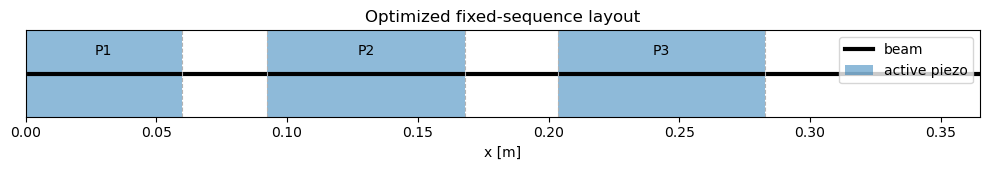

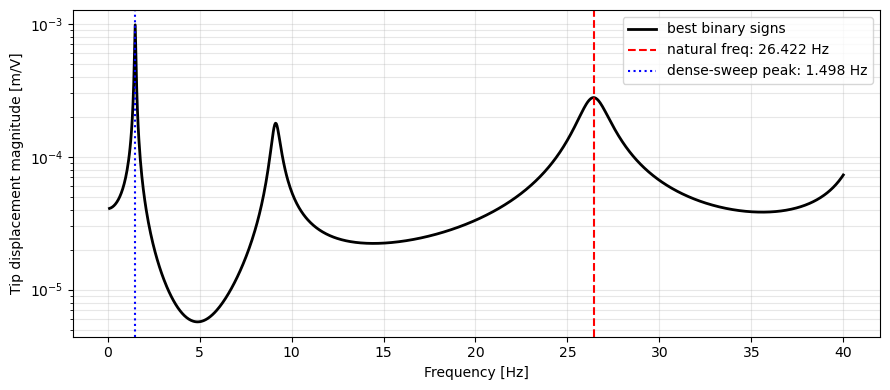

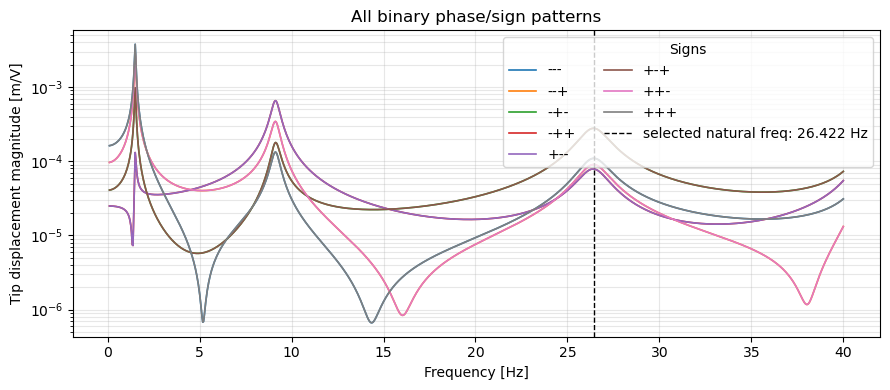

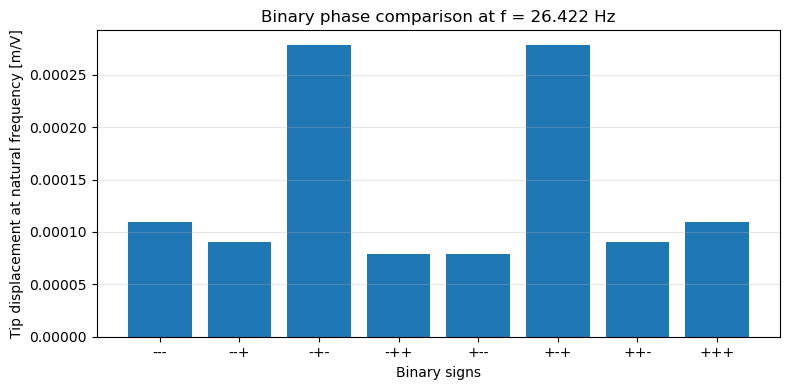

In [57]:
def plot_layout(layout, L):
    fig, ax = plt.subplots(figsize=(10, 1.8))
    ax.plot([0, L], [0, 0], "k-", lw=3, label="beam")

    # Plot active piezo spans
    for j, (a, b) in enumerate(zip(layout["xL"], layout["xR"])):
        ax.axvspan(a, b, alpha=0.5, label="active piezo" if j == 0 else None)
        ax.text(0.5*(a+b), 0.02, f"P{j+1}", ha="center", va="bottom")

    # Mark region starts
    for x in layout["x_starts"]:
        ax.axvline(x, color="0.7", lw=0.8, ls="--")

    ax.set_xlim(0, L)
    ax.set_yticks([])
    ax.set_xlabel("x [m]")
    ax.legend(loc="upper right")
    ax.set_title("Optimized fixed-sequence layout")
    plt.tight_layout()
    plt.show()

plot_layout(best_layout, L)

freq = best_sweep["freq"]
tip_disp = best_sweep["tip_disp"]

plt.figure(figsize=(9, 4))
plt.semilogy(freq, tip_disp, "k-", lw=2, label="best binary signs")
plt.axvline(best_sweep["natural_freq_hz"], color="r", ls="--", label=f"natural freq: {best_sweep['natural_freq_hz']:.3f} Hz")
plt.axvline(best_sweep["freq_peak_hz"], color="b", ls=":", label=f"dense-sweep peak: {best_sweep['freq_peak_hz']:.3f} Hz")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Tip displacement magnitude [m/V]")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: compare all binary sign patterns over the full plotting range
all_sign_sweeps = dense_all_binary_frf_for_plot(best_fe, mode_settings)

plt.figure(figsize=(9, 4))
for r in all_sign_sweeps:
    label = "".join("+" if s > 0 else "-" for s in r["signs"])
    plt.semilogy(r["freq"], r["tip_disp"], lw=1.2, label=label)

plt.axvline(best_inner["freq_hz"], color="k", ls="--", lw=1,
            label=f"selected natural freq: {best_inner['freq_hz']:.3f} Hz")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Tip displacement magnitude [m/V]")
plt.title("All binary phase/sign patterns")
plt.grid(True, which="both", alpha=0.3)
plt.legend(title="Signs", ncol=2)
plt.tight_layout()
plt.show()


# Compare all binary sign patterns at the selected natural frequency.
labels = [sign_label(r["signs"]) for r in best_inner["all_sign_results"]]
scores = [r["score"] for r in best_inner["all_sign_results"]]

plt.figure(figsize=(8, 4))
plt.bar(labels, scores)
plt.xlabel("Binary signs")
plt.ylabel("Tip displacement at natural frequency [m/V]")
plt.title(f"Binary phase comparison at f = {best_inner['freq_hz']:.3f} Hz")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Frequency-domain animation of the optimized response

This animation uses the complex FRF shape at the selected frequency:

\[
w(x,t)=\Re\{\hat{w}(x)e^{i\omega t}\}.
\]

This is much faster than a full time-domain simulation and is usually enough to visualize the optimized modal response shape.


In [58]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


def animate_frequency_domain_shape(fe, frf_record, peak_record, n_frames=80, scale=None):
    idx = int(peak_record["idx"])
    omega = 2.0 * np.pi * peak_record["freq_hz"]

    # frf['u'] excludes the fixed root displacement. Add root displacement = 0.
    u_hat_free_nodes = frf_record["frf"]["u"][idx, :]
    u_hat_nodes = np.r_[0.0 + 0.0j, u_hat_free_nodes]
    x = fe.geom.x_nodes

    if scale is None:
        max_amp = np.max(np.abs(u_hat_nodes))
        scale = 0.15 * L / max_amp if max_amp > 0 else 1.0

    fig, ax = plt.subplots(figsize=(9, 3))
    line, = ax.plot([], [], "k-", lw=2)
    pts, = ax.plot([], [], "ko", ms=3)
    ax.set_xlim(0, L)
    ax.set_ylim(-0.2*L, 0.2*L)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("scaled deflection")
    ax.set_title(f"FD response animation at natural frequency {peak_record['freq_hz']:.3f} Hz")
    ax.grid(True, alpha=0.3)

    def init():
        line.set_data([], [])
        pts.set_data([], [])
        return line, pts

    def update(k):
        phase = 2.0 * np.pi * k / n_frames
        y = scale * np.real(u_hat_nodes * np.exp(1j * phase))
        line.set_data(x, y)
        pts.set_data(x, y)
        return line, pts

    anim = FuncAnimation(fig, update, frames=n_frames, init_func=init, blit=True, interval=40)
    plt.close(fig)
    return anim

anim = animate_frequency_domain_shape(best_fe, best_inner, best_inner["peak"])
display(HTML(anim.to_jshtml()))


## 10. Optional Newmark time-domain simulation and animation

This cell is optional because time-domain simulation is much slower than the frequency-domain FRF sweep. It follows the arbitrary-placement notebook pattern using:

```python
FE_helpers.solve_newmark(...)
```

Set `RUN_TIME_DOMAIN = True` to run it.


In [28]:
RUN_TIME_DOMAIN = False


def make_time_domain_ode(fe, signs, f_hz, ms: SingleModeSettings, cs: CircuitSettings):
    signs = np.asarray(signs, dtype=float)
    omega = 2.0 * np.pi * f_hz
    A = ms.voltage_amplitude
    j_exc = list(range(len(signs)))

    def v_exc_time(t):
        t_arr = np.asarray(t)
        if t_arr.ndim == 0:
            return A * signs * np.sin(omega * float(t_arr))
        return A * signs[:, None] * np.sin(omega * t_arr[None, :])

    return fe.build_ode_system_base_excitation(
        j_exc=j_exc,
        u_base=lambda t: 0.0,
        du_base=lambda t: 0.0,
        ddu_base=lambda t: 0.0,
        R_c=cs.R_c,
        K_p=cs.K_p,
        K_i=cs.K_i,
        K_c=cs.K_c,
        v_exc=v_exc_time,
    )

if RUN_TIME_DOMAIN:
    f_drive = best_inner["freq_hz"]
    signs = best_inner["signs"]
    ode_td = make_time_domain_ode(best_fe, signs, f_drive, mode_settings, circuit_settings)

    # Use enough samples per period for a clean animation.
    dt = 1.0 / (80.0 * f_drive)
    t_end = 10.0 / f_drive

    ndof = ode_td.M.shape[0]
    result_td = FE_helpers.solve_newmark(
        ode=ode_td,
        dt=dt,
        t_end=t_end,
        beta=0.25,
        gamma=0.5,
        newton_tol=1e-7,
        newton_maxiter=20,
        x0=np.zeros(ndof),
        x_dot0=np.zeros(ndof),
        do_spectral=True,
    )

    t = result_td["t"]
    w = result_td["u"]          # shape: time x free-node displacements

    # Add fixed root displacement = 0
    w_nodes = np.column_stack([np.zeros(len(t)), w])
    x = best_fe.geom.x_nodes

    fig, ax = plt.subplots(figsize=(9, 3))
    line, = ax.plot([], [], "k-", lw=2)
    ax.set_xlim(0, L)
    max_abs = np.max(np.abs(w_nodes))
    scale = 0.15 * L / max_abs if max_abs > 0 else 1.0
    ax.set_ylim(-0.2*L, 0.2*L)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("scaled displacement")
    ax.set_title("Newmark time-domain response")
    ax.grid(True, alpha=0.3)

    stride = max(1, len(t)//120)
    frame_indices = np.arange(0, len(t), stride)

    def init():
        line.set_data([], [])
        return line,

    def update(ii):
        k = frame_indices[ii]
        line.set_data(x, scale * w_nodes[k])
        return line,

    anim_td = FuncAnimation(fig, update, frames=len(frame_indices), init_func=init, blit=True, interval=40)
    plt.close(fig)
    display(HTML(anim_td.to_jshtml()))

    # Plot FFT-based spectral estimate if available.
    if result_td.get("spectral") is not None and result_td["spectral"]["freq"] is not None:
        spec = result_td["spectral"]
        plt.figure(figsize=(9, 4))
        plt.semilogy(spec["freq"], spec["FRF"], "k-", lw=1.5)
        plt.xlabel("Frequency [Hz]")
        plt.ylabel("FFT FRF estimate")
        plt.grid(True, which="both", alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("RUN_TIME_DOMAIN is False. Set it to True to run Newmark simulation.")


RUN_TIME_DOMAIN is False. Set it to True to run Newmark simulation.


## Notes

- Every objective evaluation builds a new FE model, so mode shapes and natural frequencies change with geometry.
- The optimizer evaluates the selected mode at the natural frequency of that geometry, not by sweeping across frequency.
- This is much faster, but the exact damped FRF peak may be slightly shifted relative to the undamped natural frequency. The final dense FRF sweep is included only to verify that shift.
- `differential_evolution`, `random`, and `Powell` are all derivative-free in this notebook. Powell is local; differential evolution and random search are global/exploratory.
- This notebook is intentionally single-mode and fixed to 3 patches. For multi-mode optimization later, evaluate several `target_mode_number` values and combine their natural-frequency amplitudes in the outer objective.
